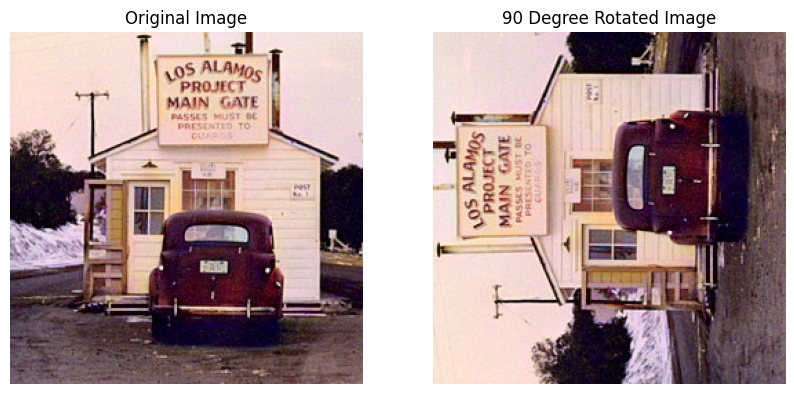

In [300]:
import os
import sys

if os.path.abspath("..") not in sys.path:
    sys.path.append(os.path.abspath(".."))

from hippy2d.utils import complex_to_rgb

# SET PYTHONPATH to the parent directory 
import sys
import os
sys.path.append(os.path.abspath(".."))

# Get testing image and its 90 degree rotation
import torch 
from torchvision import transforms
from hippy2d.utils import get_testing_img, get_default_complex
# Simulate RGB channels
test_img = get_testing_img(rgb=True)
test_img = transforms.ToTensor()(test_img).to(dtype=torch.float64)
rotated_img = torch.rot90(test_img, 1, [1, 2])

# Plot the images
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(test_img.permute(1, 2, 0).numpy(), cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(rotated_img.permute(1, 2, 0).numpy(), cmap='gray')
plt.title("90 Degree Rotated Image",)
plt.axis('off')
plt.show()


In [394]:
from escnn import nn
from escnn import gspaces
from hippy2d.learnable import flusser_basis_orders
r2_act = gspaces.rot2dOnR2(N=-1)


feat_type_in = nn.FieldType(r2_act, 3*[r2_act.irrep(0)])
feat_type_hid = nn.FieldType(r2_act, 3*[r2_act.irrep(0)] + 3 *[r2_act.irrep(1)] + 3 *[r2_act.irrep(2)])



model = torch.nn.Sequential(
    nn.R2Conv(feat_type_in, feat_type_hid, kernel_size=15),
).eval()

x = feat_type_in(test_img.unsqueeze(0).to(dtype=torch.float32))
x_rot = feat_type_in(rotated_img.unsqueeze(0).to(dtype=torch.float32))
out = model(x) # Forward pass to initialize weights
out_rot = model(x_rot)
type0, type1, type2, = out.split([3, 6])
type0_rot, type1_rot, type2_rot = out_rot.split([3, 6])

In [398]:
irrep

[[SO(2)|[irrep_0]:1, SO(2)|[irrep_0]:1, SO(2)|[irrep_0]:1],
 [SO(2)|[irrep_0]:1, SO(2)|[irrep_0]:1, SO(2)|[irrep_0]:1],
 [SO(2)|[irrep_1]:2, SO(2)|[irrep_1]:2, SO(2)|[irrep_1]:2],
 [SO(2)|[irrep_1]:2, SO(2)|[irrep_1]:2, SO(2)|[irrep_1]:2],
 [SO(2)|[irrep_2]:2, SO(2)|[irrep_2]:2, SO(2)|[irrep_2]:2],
 [SO(2)|[irrep_3]:2, SO(2)|[irrep_3]:2, SO(2)|[irrep_3]:2]]

In [391]:
feat_type_inv_out = nn.FieldType(r2_act, 3*[r2_act.irrep(0)])
layer = Irep2InvLayer(feat_type_hid).eval()
invariants = layer(out)
rot_invariants = layer(out_rot)

# assert invariance under rotation
torch.testing.assert_close(invariants, torch.rot90(rot_invariants, k=-1, dims=[-2, -1]),rtol=1e-5, atol=1e-5)

In [392]:
layer.symmetric_idx 

tensor([3])

NameError: name 'flusser_basis_orders' is not defined